In [1]:
import numpy as np

from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G0_muS
from superconductivity.api import NDArray64

from IPython import get_ipython

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic(
        "config", "InlineBackend.rc = {'figure.dpi': 300}"
    )  # choose a value you like

np.float64(45.286842105263155)

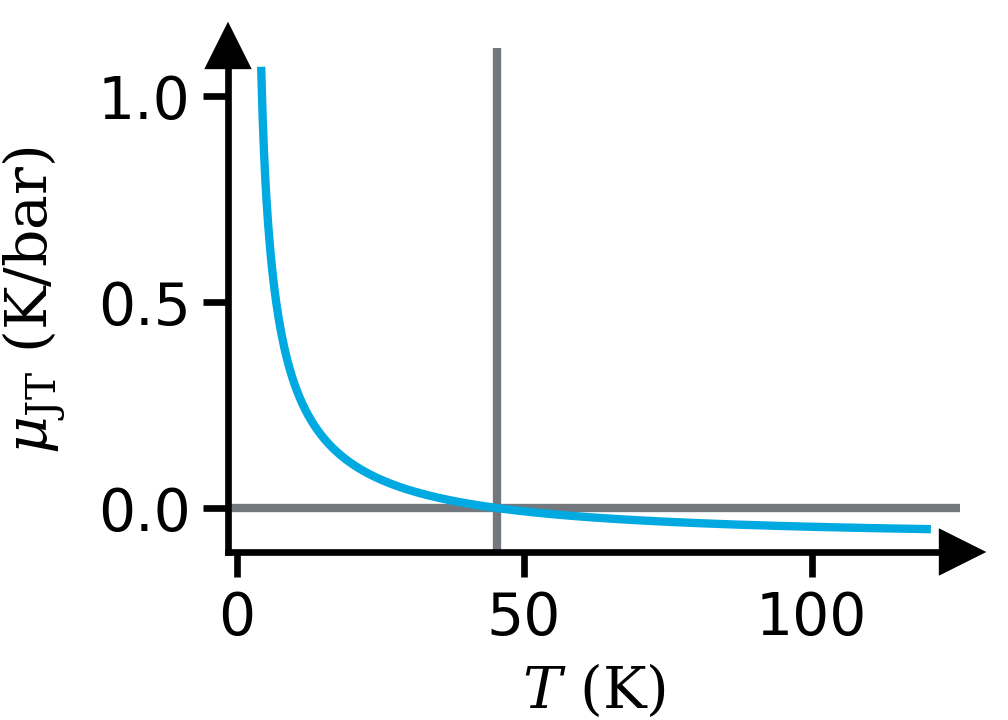

In [2]:
import CoolProp.CoolProp as CP

T = np.linspace(4.3, 120, 495)  # K
pressures_bar = [1, 5, 10, 20, 50]
pressures_bar = [1]

figsize = (1.68, 1.2)
fig, ax = sc.get_figure(figsize=figsize, padding=(0.3, 0.2))

ax.axhline(0, lw=1, color=sc.seegrau100)
for p_bar in pressures_bar:
    p = p_bar * 1e5  # bar -> Pa
    mu = np.array([CP.PropsSI("d(T)/d(P)|H", "T", Ti, "P", p, "Helium") for Ti in T])
    T0 = T[np.argmin(np.abs(mu))]
    ax.axvline(T0, color=sc.seegrau100)
    ax.plot(T, mu * 1e5, label=f"{p_bar} bar", color=sc.seeblau100)  # K/Pa -> K/bar

# plt.xlabel("T (K)")
# plt.ylabel(r"$\mu_\mathrm{JT}$ (K/bar)")
# # plt.legend()
# plt.show()

xlabel = "$T\\ \\mathrm{(K)}$"
ylabel = "$\\mu_\\mathrm{JT}\\ \\mathrm{(K/bar)}$"
title = "methods/setup/joule-thomson"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
T0

In [111]:
# phase diagram data
dilution = np.array(
    [
        [0.06285714285714317, 0],
        [0.06857142857142895, 0.06878980891719744],
        [0.0771428571428574, 0.1375796178343951],
        [0.10571428571428587, 0.24649681528662426],
        [0.14285714285714324, 0.3496815286624204],
        [0.18000000000000016, 0.4242038216560511],
        [0.20857142857142885, 0.47579617834394905],
        [0.245714285714286, 0.5331210191082802],
        [0.27714285714285747, 0.5789808917197452],
        [0.30857142857142883, 0.6191082802547772],
        [0.3371428571428574, 0.6477707006369429],
        [0.37714285714285745, 0.6878980891719746],
        [0.41714285714285737, 0.7222929936305733],
        [0.4571428571428574, 0.7509554140127388],
        [0.5085714285714288, 0.7910828025477707],
        [0.5485714285714288, 0.8140127388535032],
        [0.5971428571428575, 0.8426751592356687],
        [0.6428571428571431, 0.8598726114649682],
        [0.6714285714285717, 0.8713375796178344],
    ]
)

separation = np.array(
    [
        [1, 0.1433121019108281],
        [0.9942857142857144, 0.1949044585987263],
        [0.9885714285714288, 0.23503184713375802],
        [0.9771428571428574, 0.3],
        [0.9714285714285718, 0.32675159235668794],
        [0.9542857142857146, 0.3783439490445861],
        [0.9371428571428574, 0.41847133757961785],
        [0.9200000000000004, 0.4585987261146498],
        [0.8971428571428572, 0.5044585987261145],
        [0.8771428571428574, 0.5388535031847135],
        [0.8542857142857145, 0.5789808917197452],
        [0.8342857142857146, 0.6191082802547772],
        [0.8171428571428574, 0.6420382165605096],
        [0.7971428571428574, 0.6764331210191084],
        [0.782857142857143, 0.6993630573248408],
        [0.7714285714285718, 0.7222929936305733],
        [0.7571428571428573, 0.7394904458598728],
        [0.7457142857142861, 0.756687898089172],
        [0.7342857142857145, 0.7796178343949045],
        [0.7171428571428575, 0.802547770700637],
        [0.7028571428571431, 0.8197452229299365],
        [0.6828571428571432, 0.8541401273885352],
        [0.6714285714285717, 0.8713375796178344],
    ]
)

lambda_line = np.array(
    [
        [0.23686507936507972, 1.7985403397027602],
        [0.250092592592593, 1.778635881104034],
        [0.26166666666666705, 1.758731422505308],
        [0.2732407407407411, 1.742144373673036],
        [0.28646825396825437, 1.72223991507431],
        [0.3013492063492068, 1.6923832271762207],
        [0.3112698412698417, 1.675796178343949],
        [0.32615079365079414, 1.6492569002123143],
        [0.3393783068783074, 1.6260350318471337],
        [0.3542592592592597, 1.599495753715499],
        [0.37079365079365123, 1.5663216560509554],
        [0.39559523809523855, 1.5165605095541401],
        [0.4071693121693126, 1.4933386411889595],
        [0.42205026455026495, 1.460164543524416],
        [0.4352777777777782, 1.4336252653927812],
        [0.45181216931216983, 1.3971337579617833],
        [0.47000000000000053, 1.3606422505307854],
        [0.4832275132275138, 1.330785562632696],
        [0.4964550264550269, 1.300928874734607],
        [0.5096825396825401, 1.2677547770700637],
        [0.5196031746031751, 1.244532908704883],
        [0.5344841269841274, 1.2080414012738854],
        [0.5460582010582015, 1.1781847133757961],
        [0.5642460317460323, 1.1350583864118895],
        [0.5791269841269847, 1.0985668789808916],
        [0.5989682539682545, 1.0488057324840763],
        [0.6155026455026461, 1.008996815286624],
        [0.6287301587301594, 0.9758227176220805],
        [0.6452645502645508, 0.9326963906581739],
        [0.6584920634920639, 0.8995222929936304],
        [0.6714285714285717, 0.8713375796178344],
    ]
)
brewer = np.array([[0.9991005291005297, 0.14315286624203782]])
edwards = np.array(
    [
        [0.08144179894179948, 0.1597399150743095],
        [0.09962962962962996, 0.2061836518046707],
        [0.11947089947089973, 0.285801486199575],
        [0.15088624338624368, 0.36541932059447957],
    ]
)
debuyn = np.array(
    [
        [0.28977513227513274, 1.7156050955414013],
        [0.3889814814814819, 1.5364649681528662],
        [0.47826719576719623, 1.3506900212314223],
        [0.572513227513228, 1.1483280254777068],
        [0.6386507936507942, 0.9526008492569],
        [0.6998280423280429, 0.8265392781316345],
        [0.7494312169312175, 0.7568736730360932],
        [0.8039947089947097, 0.6673036093418256],
        [0.8469841269841275, 0.5976380042462841],
        [0.8932804232804238, 0.4981157112526535],
        [0.9544576719576725, 0.3786889596602969],
        [0.6386507936507942, 0.8696656050955414],
        [0.572513227513228, 0.8398089171974521],
        [0.47661375661375716, 0.7701433121019108],
        [0.38732804232804274, 0.6938428874734606],
        [0.2914285714285718, 0.5876857749469211],
        [0.1492328042328046, 0.3919585987261145],
    ]
)

ValueError: Error measuring {\sffamily\fontsize{5.000000}{6.000000}\selectfont\catcode`\^=\active\def^{\ifmmode\sp\else\^{}\fi}\catcode`\%=\active\def%{\%}Fermi fluid \textsuperscript{\xxx-small 3}He}
LaTeX Output:
! Undefined control sequence.
<argument> ... \sf@size \sf@size \selectfont \xxx 
                                                  -small 3
<*> ...mi fluid \textsuperscript{\xxx-small 3}He}}
                                                  \typeout{\the\wd0,\the\ht0...
!  ==> Fatal error occurred, no output PDF file produced!
Transcript written on texput.log.


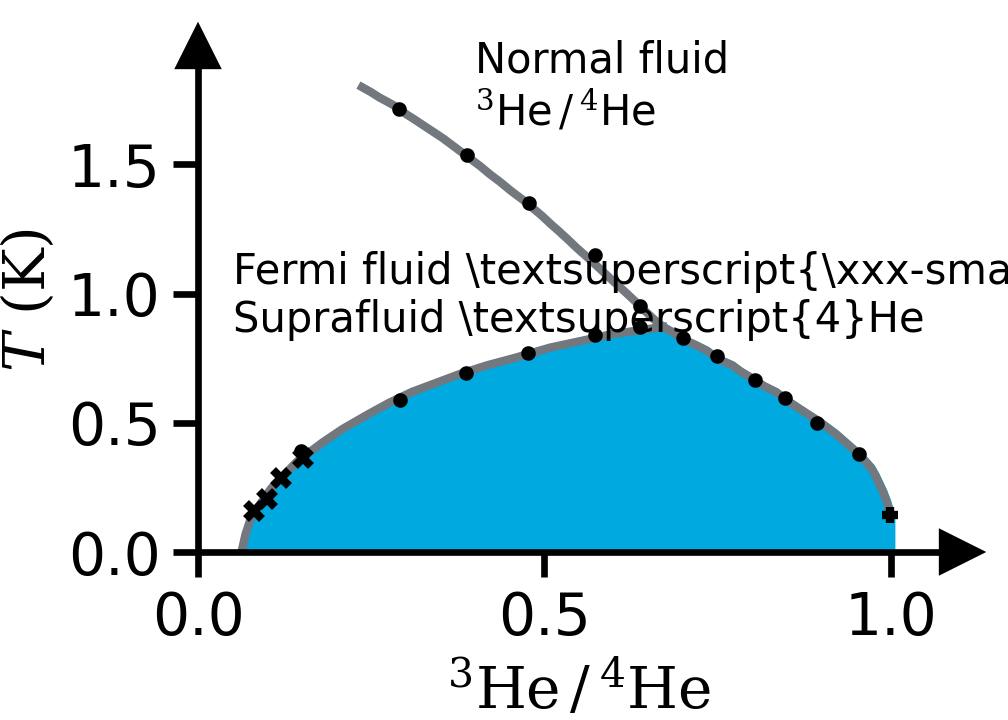

In [ ]:
fig, ax = sc.get_figure(figsize=(1.68, 1.2), padding=(0.25, 0.2))

ax.plot(lambda_line[:, 0], lambda_line[:, 1], "-", color=sc.seegrau100)
ax.plot(separation[:, 0], separation[:, 1], "-", color=sc.seegrau100)
ax.plot(dilution[:, 0], dilution[:, 1], "-", color=sc.seegrau100)

import matplotlib as mpl

mpl.rcParams.update(
    {
        "pgf.texsystem": "pdflatex",
        "pgf.rcfonts": False,
        "pgf.preamble": r"""
\newcommand{\hethree}{\textsuperscript{3}He}
\newcommand{\hefour}{\textsuperscript{4}He}
""",
    }
)

ax.plot(
    brewer[:, 0],
    brewer[:, 1],
    "+",
    ms=2,
    color="k",
    label="\\cite{brewer_phase_1962}",
)
ax.plot(
    edwards[:, 0],
    edwards[:, 1],
    "x",
    ms=2,
    color="k",
    label="\\cite{edwards_solubility_1965}",
)
ax.plot(
    debuyn[:, 0],
    debuyn[:, 1],
    ".",
    ms=1.5,
    color="k",
    label="\\cite{de_bruyn_ouboter_thermodynamic_1960}",
)
ax.fill_between(
    x=np.concatenate((dilution[:, 0], np.flip(separation[:, 0]))),
    y1=np.concatenate((dilution[:, 1], np.flip(separation[:, 1]))),
    y2=0,
    color=sc.seeblau100,
)

ax.set_ylim(0, 1.95)
ax.set_xlim(0, 1.1)
# ax.legend(
#     title="Refs.",
#     handlelength=0.0,
#     loc="upper right",
#     frameon=False,
#     fontsize=6,
#     title_fontsize=6,
#     ncols=1,
#     columnspacing=0.3,
#     borderpad=0.1,  # reduces padding inside the legend box
# )

ax.annotate(
    "Normal fluid\n" + "$^3$He$\\,/\\,^4$He",
    xy=(0.4, 1.65),
    fontsize=5,
)

ax.annotate(
    "Fermi fluid "
    + r"\textsuperscript{\tiny 3}He"
    + "\n"
    + "Suprafluid "
    + r"\textsuperscript{4}He",
    xy=(0.05, 0.85),
    fontsize=5,
)

xlabel = "$^{3}\\mathrm{He}\\,/\\,^{4}\\mathrm{He}$"
ylabel = "$T\\ \\mathrm{(K)}$"
title = "methods/setup/phase-diagram"

sc.theory_layout(fig, ax, title, xlabel, ylabel)